# Chapter 2: Multivariable Optimization


> **Source and scope.** This is an original computational companion to Mark M. Meerschaert, *Mathematical Modeling*, 4th ed. (Academic Press, 2013). It follows the chapter structure and reconstructs representative models in Python. It does not reproduce the textbook's prose, figures, or complete exercise sets. Equations, numerical assumptions, and example names are attributed to the book.


This notebook follows Sections 2.1-2.3: unconstrained optimization, Lagrange multipliers, sensitivity analysis, and shadow prices. The running example is the two-product color-TV model.


In [1]:
from __future__ import annotations

import platform
import warnings
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sympy as sp
from IPython.display import display

warnings.filterwarnings("ignore", category=RuntimeWarning)
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (8, 4.8)

SEED = 20260731
rng = np.random.default_rng(SEED)

versions = pd.Series({
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "SciPy": scipy.__version__,
    "SymPy": sp.__version__,
    "pandas": pd.__version__,
    "Matplotlib": version("matplotlib"),
}, name="version")
display(versions.to_frame())


,version
Python,3.13.5
NumPy,2.3.5
SciPy,1.17.0
SymPy,1.14.0
pandas,2.2.3
Matplotlib,3.10.8


## 2.1 Unconstrained optimization

Let \(x_1\) and \(x_2\) denote annual sales of 19-inch and 21-inch sets. Prices fall with own sales and cross-product sales. Profit is revenue minus fixed and variable manufacturing cost.


In [2]:
x1, x2, a, capacity = sp.symbols("x1 x2 a capacity", positive=True, real=True)

profit_tv = (
    (339 - sp.Rational(1, 100) * x1 - sp.Rational(3, 1000) * x2) * x1
    + (399 - sp.Rational(4, 1000) * x1 - sp.Rational(1, 100) * x2) * x2
    - (400_000 + 195 * x1 + 225 * x2)
)

grad = sp.Matrix([sp.diff(profit_tv, x1), sp.diff(profit_tv, x2)])
hessian = sp.hessian(profit_tv, (x1, x2))
stationary = sp.solve(list(grad), (x1, x2), dict=True)[0]
stationary_profit = sp.simplify(profit_tv.subs(stationary))

print("Gradient:")
display(grad)
print("Hessian:")
display(hessian)
print("Unconstrained optimum:")
display(stationary)
display(sp.Eq(sp.Symbol("P_max"), stationary_profit))

hessian_eigs = [float(v) for v in hessian.eigenvals().keys()]
assert all(v < 0 for v in hessian_eigs)


Gradient:


Matrix([
[-x1/50 - 7*x2/1000 + 144],
[-7*x1/1000 - x2/50 + 174]])

Hessian:


Matrix([
[  -1/50, -7/1000],
[-7/1000,   -1/50]])

Unconstrained optimum:


{x1: 554000/117, x2: 824000/117}

Eq(P_max, 21592000/39)

In [3]:
ux1 = float(stationary[x1])
ux2 = float(stationary[x2])
up = float(stationary_profit)

summary = pd.DataFrame({
    "decision": ["19-inch sets", "21-inch sets", "annual profit"],
    "value": [ux1, ux2, up],
    "unit": ["sets", "sets", "dollars"],
})
display(summary)

assert np.isclose(ux1, 554_000 / 117)
assert np.isclose(ux2, 824_000 / 117)


,decision,value,unit
0,19-inch sets,4735.042735,sets
1,21-inch sets,7042.735043,sets
2,annual profit,553641.025641,dollars


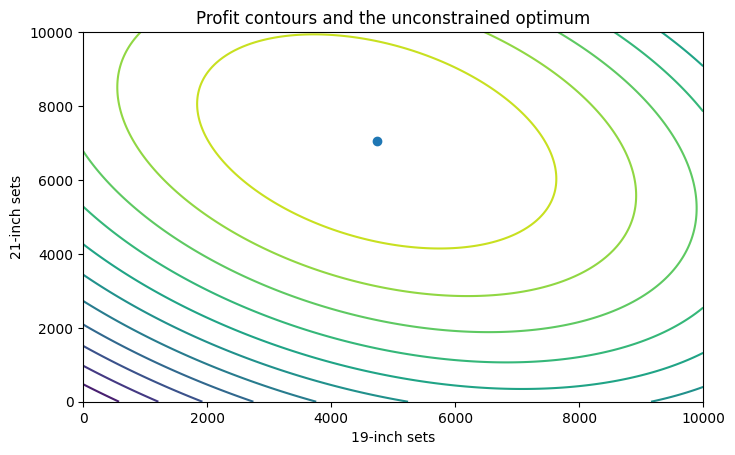

In [4]:
profit_tv_fn = sp.lambdify((x1, x2), profit_tv, "numpy")
xx = np.linspace(0, 10_000, 160)
yy = np.linspace(0, 10_000, 160)
XX, YY = np.meshgrid(xx, yy)
ZZ = profit_tv_fn(XX, YY)

plt.contour(XX, YY, ZZ, levels=14)
plt.scatter([ux1], [ux2], zorder=3)
plt.xlabel("19-inch sets")
plt.ylabel("21-inch sets")
plt.title("Profit contours and the unconstrained optimum")
plt.show()


## 2.2 Lagrange multipliers and inequality constraints

Production is limited by

\[
x_1\le 5000,\qquad x_2\le 8000,\qquad x_1+x_2\le 10000.
\]

The total-capacity constraint binds at the optimum. We solve it symbolically and independently verify it with a numerical constrained optimizer.


In [5]:
lagrange_multiplier = sp.symbols("lambda", real=True)
lagrangian = profit_tv - lagrange_multiplier * (x1 + x2 - capacity)
lagrange_solution = sp.solve(
    [sp.diff(lagrangian, x1), sp.diff(lagrangian, x2), x1 + x2 - capacity],
    (x1, x2, lagrange_multiplier),
    dict=True,
)[0]
lagrange_at_10k = {key: sp.simplify(value.subs(capacity, 10_000)) for key, value in lagrange_solution.items()}
constrained_profit = sp.simplify(profit_tv.subs(lagrange_at_10k))

display(lagrange_at_10k)
display(sp.Eq(sp.Symbol("P_constrained"), constrained_profit))


{lambda: 24, x1: 50000/13, x2: 80000/13}

Eq(P_constrained, 6920000/13)

In [6]:
from scipy.optimize import minimize

# SLSQP is noticeably more reliable when the decision variables are scaled to
# order-one values. Optimizing raw production counts near 10,000 can trigger
# a false termination on some SciPy/BLAS builds.
SCALE_X = 10_000.0
SCALE_P = 100_000.0

def neg_scaled_profit(u):
    x = SCALE_X * np.asarray(u, dtype=float)
    return -float(profit_tv_fn(x[0], x[1])) / SCALE_P

def neg_scaled_profit_jac(u):
    x_1, x_2 = SCALE_X * np.asarray(u, dtype=float)
    grad_profit = np.array([
        144 - 0.02 * x_1 - 0.007 * x_2,
        174 - 0.007 * x_1 - 0.02 * x_2,
    ])
    return -(SCALE_X / SCALE_P) * grad_profit

constraints = [
    {"type": "ineq", "fun": lambda u: 0.5 - u[0], "jac": lambda u: np.array([-1.0, 0.0])},
    {"type": "ineq", "fun": lambda u: 0.8 - u[1], "jac": lambda u: np.array([0.0, -1.0])},
    {"type": "ineq", "fun": lambda u: 1.0 - u[0] - u[1], "jac": lambda u: np.array([-1.0, -1.0])},
]
result_scaled = minimize(
    neg_scaled_profit,
    x0=np.array([0.38, 0.62]),
    jac=neg_scaled_profit_jac,
    bounds=[(0, None), (0, None)],
    constraints=constraints,
    method="SLSQP",
    options={"ftol": 1e-12, "maxiter": 1000},
)

# Convert the optimizer output back to the physical units used below.
result = result_scaled
result.x = SCALE_X * result_scaled.x
result.fun = SCALE_P * result_scaled.fun

numeric_solution = pd.Series({
    "x1": result.x[0],
    "x2": result.x[1],
    "profit": -result.fun,
    "capacity used": result.x.sum(),
    "success": result.success,
})
display(numeric_solution.to_frame("value"))

assert result.success, result.message
assert np.allclose(result.x, [50_000 / 13, 80_000 / 13], atol=1e-3)


,value
x1,3846.153846
x2,6153.846154
profit,532307.692308
capacity used,10000.0
success,True


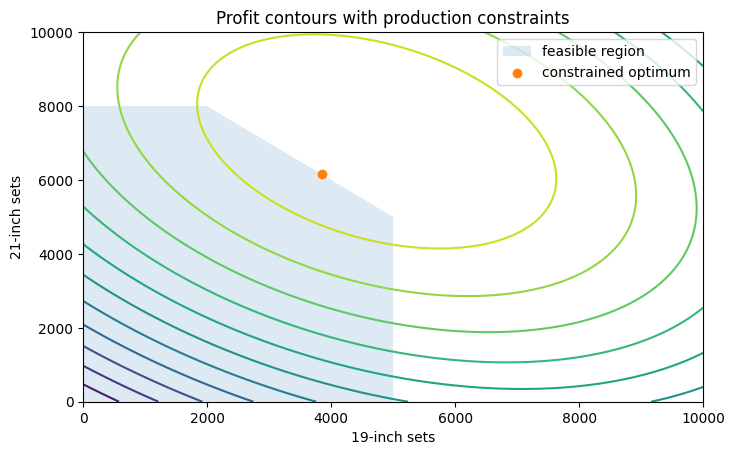

In [7]:
feasible_x = np.array([0, 5_000, 5_000, 2_000, 0, 0])
feasible_y = np.array([0, 0, 5_000, 8_000, 8_000, 0])

plt.contour(XX, YY, ZZ, levels=14)
plt.fill(feasible_x, feasible_y, alpha=0.15, label="feasible region")
plt.scatter([result.x[0]], [result.x[1]], zorder=3, label="constrained optimum")
plt.xlabel("19-inch sets")
plt.ylabel("21-inch sets")
plt.title("Profit contours with production constraints")
plt.legend()
plt.show()


## 2.3 Shadow prices

For a binding equality \(x_1+x_2=c\), the Lagrange multiplier is the local increase in optimal profit from one additional unit of capacity.


In [8]:
capacity_solution = {key: sp.simplify(value) for key, value in lagrange_solution.items()}
optimal_profit_by_capacity = sp.simplify(profit_tv.subs(capacity_solution))
shadow_from_derivative = sp.simplify(sp.diff(optimal_profit_by_capacity, capacity))

print("Optimal decisions as functions of capacity:")
display(capacity_solution)
print("Derivative of optimal profit with respect to capacity:")
display(sp.Eq(sp.Symbol("dP_dc"), shadow_from_derivative))

shadow_10k = float(shadow_from_derivative.subs(capacity, 10_000))
print(f"Shadow price at 10,000 units: ${shadow_10k:.2f} per added unit")

profit_10k = float(optimal_profit_by_capacity.subs(capacity, 10_000))
profit_10001 = float(optimal_profit_by_capacity.subs(capacity, 10_001))
print(f"Finite difference check: ${profit_10001 - profit_10k:.4f}")
assert np.isclose(shadow_10k, 24.0)


Optimal decisions as functions of capacity:


{lambda: 159 - 27*capacity/2000,
 x1: capacity/2 - 15000/13,
 x2: capacity/2 + 15000/13}

Derivative of optimal profit with respect to capacity:


Eq(dP_dc, 159 - 27*capacity/2000)

Shadow price at 10,000 units: $24.00 per added unit
Finite difference check: $23.9933


## Sensitivity to the 19-inch own-price coefficient

Replace 0.01 by \(a\). The constrained optimum remains on \(x_1+x_2=10000\) over a neighborhood of the baseline. Symbolic formulas make the sensitivity calculation cheap, which is one of the few mercies algebra grants us.


In [9]:
profit_a = (
    (339 - a * x1 - sp.Rational(3, 1000) * x2) * x1
    + (399 - sp.Rational(4, 1000) * x1 - sp.Rational(1, 100) * x2) * x2
    - (400_000 + 195 * x1 + 225 * x2)
)
lagrangian_a = profit_a - lagrange_multiplier * (x1 + x2 - 10_000)
solution_a = sp.solve(
    [sp.diff(lagrangian_a, x1), sp.diff(lagrangian_a, x2), x1 + x2 - 10_000],
    (x1, x2, lagrange_multiplier),
    dict=True,
)[0]
profit_opt_a = sp.simplify(profit_a.subs(solution_a))

sensitivity_a = {}
for output_name, expression in {
    "x1": solution_a[x1],
    "x2": solution_a[x2],
    "profit": profit_opt_a,
}.items():
    sensitivity_a[output_name] = sp.simplify(sp.diff(expression, a) * a / expression)

display(solution_a)
display(pd.Series({k: float(v.subs(a, 0.01)) for k, v in sensitivity_a.items()}, name="S(output, a)"))


{lambda: (572 - 26000*a)/(1000*a + 3),
 x1: 50000/(1000*a + 3),
 x2: (10000000*a - 20000)/(1000*a + 3)}

x1       -0.769231
x2        0.480769
profit   -0.277901
Name: S(output, a), dtype: float64

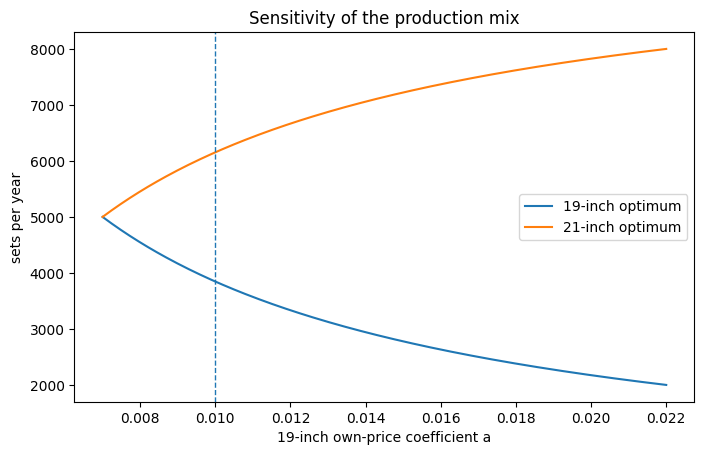

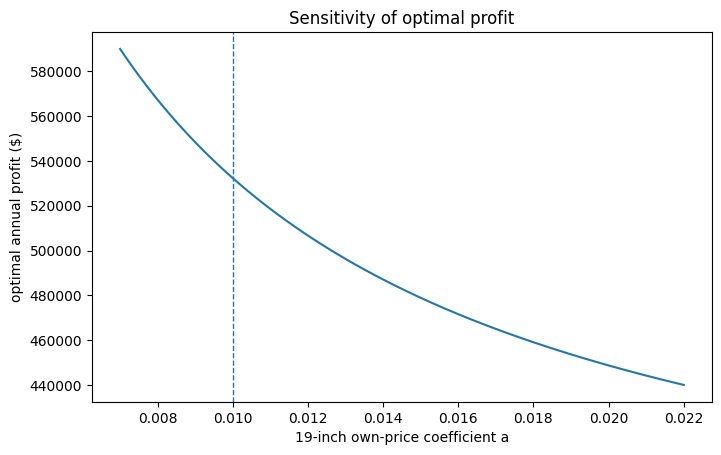

In [10]:
a_grid = np.linspace(0.007, 0.022, 250)
x1_a = sp.lambdify(a, solution_a[x1], "numpy")(a_grid)
x2_a = sp.lambdify(a, solution_a[x2], "numpy")(a_grid)
p_a = sp.lambdify(a, profit_opt_a, "numpy")(a_grid)

plt.plot(a_grid, x1_a, label="19-inch optimum")
plt.plot(a_grid, x2_a, label="21-inch optimum")
plt.axvline(0.01, linestyle="--", linewidth=1)
plt.xlabel("19-inch own-price coefficient a")
plt.ylabel("sets per year")
plt.title("Sensitivity of the production mix")
plt.legend()
plt.show()

plt.plot(a_grid, p_a)
plt.axvline(0.01, linestyle="--", linewidth=1)
plt.xlabel("19-inch own-price coefficient a")
plt.ylabel("optimal annual profit ($)")
plt.title("Sensitivity of optimal profit")
plt.show()


In [11]:
nominal_decision = np.array([50_000 / 13, 80_000 / 13])
actual_a = 0.011
actual_optimum = np.array([
    float(solution_a[x1].subs(a, actual_a)),
    float(solution_a[x2].subs(a, actual_a)),
])
profit_actual_fn = sp.lambdify((x1, x2), profit_a.subs(a, actual_a), "numpy")
profit_nominal_decision = float(profit_actual_fn(*nominal_decision))
profit_reoptimized = float(profit_actual_fn(*actual_optimum))

robustness = pd.Series({
    "actual optimal x1": actual_optimum[0],
    "actual optimal x2": actual_optimum[1],
    "profit using nominal decision": profit_nominal_decision,
    "profit after reoptimization": profit_reoptimized,
    "relative decision-loss (%)": 100 * (profit_reoptimized - profit_nominal_decision) / profit_reoptimized,
})
display(robustness.to_frame("value"))


,value
actual optimal x1,3571.428571
actual optimal x2,6428.571429
profit using nominal decision,517514.792899
profit after reoptimization,518571.428571
relative decision-loss (%),0.203759


## Chapter checkpoint

The constrained optimum uses all total capacity, while the individual circuit-board limits are slack. The binding resource has a positive shadow price; nonbinding resources have zero local value. Decision variables can be fairly sensitive while profit remains robust because the objective surface is flat near its maximum.
